# Notebook 1 — RT-DETRv4-X: PPE Detection
### Cell 1: Environment Setup
Install dependencies, verify GPU, mount Google Drive.

In [ ]:
# ── Install dependencies ────────────────────────────────────────────────────
!pip install -q ultralytics supervision scikit-learn pandas matplotlib seaborn

import torch
import os

# Verify GPU
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU : {gpu_name}")
    print(f"VRAM: {vram_gb:.2f} GB")
else:
    print("WARNING: No GPU detected. Training will be extremely slow.")

# Speed up convolutions when input size is fixed
torch.backends.cudnn.benchmark = True

# # ── Mount Google Drive ──────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/drive')

# Create base output directory
BASE_DIR = "/drive/MyDrive/ppe_results"
os.makedirs(BASE_DIR, exist_ok=True)
print(f"Drive output directory ready: {BASE_DIR}")

GPU : Tesla T4
VRAM: 15.64 GB
Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
Drive output directory ready: /drive/MyDrive/ppe_results


---
### Cell 2: Dataset Preparation
Download from Kaggle, filter to 4 PPE classes, remap IDs, write YAML, visualize samples.

**Before running:** Upload your `kaggle.json` API token to Colab using:
```python
from google.colab import files
files.upload()  # upload kaggle.json
```
Or place it at `/root/.kaggle/kaggle.json` manually.

In [ ]:
import os, shutil, glob, json, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import supervision as sv
from pathlib import Path
from collections import Counter

# ── Kaggle setup — auto-detects kaggle.json from multiple locations ─────────
import os, shutil
from pathlib import Path

KAGGLE_DIR = Path("/root/.kaggle")
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
KAGGLE_DEST = KAGGLE_DIR / "kaggle.json"

# Search order: already in place → /content/ upload → Drive
search_paths = [
    KAGGLE_DEST,                                      # already correct location
    Path("/content/kaggle.json"),                     # uploaded via files.upload()
    Path("/drive/MyDrive/kaggle.json"),               # stored on Drive
    Path("/drive/MyDrive/ppe_results/kaggle.json"),   # alt Drive location
]

found = False
for p in search_paths:
    if p.exists() and p != KAGGLE_DEST:
        shutil.copy(p, KAGGLE_DEST)
        print(f"Copied kaggle.json from {p}")
        found = True
        break
    elif p == KAGGLE_DEST and p.exists():
        print(f"kaggle.json already at {KAGGLE_DEST}")
        found = True
        break

if not found:
    # Last resort: prompt user to upload now
    print("kaggle.json not found in any expected location.")
    print("Launching upload dialog — please select your kaggle.json file:")
    from google.colab import files
    uploaded = files.upload()  # blocks until user uploads
    if "kaggle.json" in uploaded:
        shutil.move("/content/kaggle.json", KAGGLE_DEST)
        print("kaggle.json uploaded and moved.")
        found = True
    else:
        raise FileNotFoundError(
            "kaggle.json not uploaded. "
            "Download it from https://www.kaggle.com/settings → API → Create New Token"
        )

# Lock permissions (Kaggle CLI requires 600)
os.chmod(KAGGLE_DEST, 0o600)
print(f"kaggle.json ready at {KAGGLE_DEST}")

# Verify the JSON is valid and has required keys
import json
with open(KAGGLE_DEST) as f:
    creds = json.load(f)
assert "username" in creds and "key" in creds, \
    "kaggle.json is missing 'username' or 'key'. Download a fresh token from kaggle.com/settings."
print(f"Authenticated as Kaggle user: {creds['username']}")

# ── Download dataset ─────────────────────────────────────────────────────────
!kaggle datasets download -d athithyakrishnaa/ppe-clean-dataset -p /content/ --unzip

# Inspect extracted folder structure
!find /content -maxdepth 3 -type d | grep -v '__pycache__' | head -30
!find /content -name '*.yaml' | head -5

kaggle.json already at /root/.kaggle/kaggle.json
kaggle.json ready at /root/.kaggle/kaggle.json
Authenticated as Kaggle user: athithyakrishnaa
Dataset URL: https://www.kaggle.com/datasets/athithyakrishnaa/ppe-clean-dataset
License(s): unknown
 67% 99.0M/149M [00:00<00:00, 1.04GB/s]
100% 149M/149M [00:00<00:00, 612MB/s]  
/content
/content/.config
/content/.config/configurations
/content/.config/logs
/content/.config/logs/2026.02.06
/content/dataset
/content/dataset/train
/content/dataset/train/labels
/content/dataset/train/images
/content/dataset/test
/content/dataset/test/labels
/content/dataset/test/images
/content/dataset/valid
/content/dataset/valid/labels
/content/dataset/valid/images
/content/ppe_multiclass_dataset
/content/ppe_multiclass_dataset/train
/content/ppe_multiclass_dataset/train/labels
/content/ppe_multiclass_dataset/train/images
/content/ppe_multiclass_dataset/test
/content/ppe_multiclass_dataset/test/labels
/content/ppe_multiclass_dataset/test/images
/content/ppe_mul

In [ ]:
# ── Discover dataset root ────────────────────────────────────────────────────
# Adjust RAW_ROOT if the extracted folder name differs
# Common patterns after extraction:
import glob as _glob

candidates = _glob.glob("/content/**/data.yaml", recursive=True) + \
             _glob.glob("/content/**/*.yaml", recursive=True)
print("Found YAML files:", candidates[:5])

# ── Read original classes from the dataset YAML ──────────────────────────────
import yaml

# Set this to the actual yaml path found above
ORIGINAL_YAML = candidates[0] if candidates else "/content/ppe-clean-dataset/data.yaml"
RAW_ROOT      = str(Path(ORIGINAL_YAML).parent)
print(f"Dataset root: {RAW_ROOT}")

with open(ORIGINAL_YAML) as f:
    orig_meta = yaml.safe_load(f)

orig_names = orig_meta.get("names", [])
print("Original classes:", orig_names)
print("Original nc:", orig_meta.get("nc"))

Found YAML files: ['/content/ppe_multiclass_dataset/data.yaml', '/content/dataset/ppe_data.yaml', '/content/ppe_multiclass_dataset/data.yaml']
Dataset root: /content/ppe_multiclass_dataset
Original classes: {0: 'Hardhat', 1: 'Mask', 2: 'NO-Hardhat', 3: 'NO-Mask', 4: 'NO-Safety Vest', 5: 'Person', 6: 'Safety Cone', 7: 'Safety Vest', 8: 'machinery', 9: 'vehicle'}
Original nc: 10


In [ ]:
import yaml

# ── Re-load original YAML ─────────────────────────────────────────────────────
with open(ORIGINAL_YAML) as f:
    orig_meta = yaml.safe_load(f)

orig_names = orig_meta.get("names", [])

# Normalise to {int_id: str_name}
if isinstance(orig_names, dict):
    id_to_name = {int(k): str(v) for k, v in orig_names.items()}
else:
    id_to_name = {i: str(v) for i, v in enumerate(orig_names)}

print("Normalised id_to_name:", id_to_name)

# ── Explicit mapping: original dataset names → new IDs ───────────────────────
# Dataset uses: Hardhat / NO-Hardhat / Safety Vest / NO-Safety Vest
# We map to:    Helmet=0 / No Helmet=1 / Safety Vest=2 / No Safety Vest=3
EXPLICIT_MAP = {
    "Hardhat":        0,   # → Helmet
    "NO-Hardhat":     1,   # → No Helmet
    "Safety Vest":    2,   # → Safety Vest
    "NO-Safety Vest": 3,   # → No Safety Vest
}

orig_to_new = {}
for old_id, name in id_to_name.items():
    if name in EXPLICIT_MAP:
        orig_to_new[old_id] = EXPLICIT_MAP[name]

print("\nMapping (original ID → new ID):", orig_to_new)
print("Classes kept:", {id_to_name[k]: v for k, v in orig_to_new.items()})

# Expected: {0: 0, 2: 1, 7: 2, 4: 3}
mapped_new = set(orig_to_new.values())
assert mapped_new == {0, 1, 2, 3}, \
    f"Missing classes! Mapped new IDs: {mapped_new}.\n" \
    f"Original names: {list(id_to_name.values())}\n" \
    "Update EXPLICIT_MAP keys to match the names above exactly."

# Also update CLASS_NAMES for all downstream cells
CLASS_NAMES = ["Helmet", "No Helmet", "Safety Vest", "No Safety Vest"]
print("\nCLASS_NAMES for downstream use:", CLASS_NAMES)

Normalised id_to_name: {0: 'Hardhat', 1: 'Mask', 2: 'NO-Hardhat', 3: 'NO-Mask', 4: 'NO-Safety Vest', 5: 'Person', 6: 'Safety Cone', 7: 'Safety Vest', 8: 'machinery', 9: 'vehicle'}

Mapping (original ID → new ID): {0: 0, 2: 1, 4: 3, 7: 2}
Classes kept: {'Hardhat': 0, 'NO-Hardhat': 1, 'NO-Safety Vest': 3, 'Safety Vest': 2}

CLASS_NAMES for downstream use: ['Helmet', 'No Helmet', 'Safety Vest', 'No Safety Vest']


In [ ]:
# ── Filter & remap labels into new dataset folder ────────────────────────────
DATASET_OUT = "/content/dataset"

def process_split(split_name):
    """Filter and remap one split (train / valid / test)."""
    # Support both 'valid' and 'val' naming conventions
    for candidate_name in [split_name, split_name.replace("valid", "val"),
                            split_name.replace("val", "valid")]:
        img_dir = Path(RAW_ROOT) / candidate_name / "images"
        lbl_dir = Path(RAW_ROOT) / candidate_name / "labels"
        if img_dir.exists():
            break
    else:
        print(f"  WARNING: split '{split_name}' not found, skipping.")
        return 0

    out_img = Path(DATASET_OUT) / split_name / "images"
    out_lbl = Path(DATASET_OUT) / split_name / "labels"
    out_img.mkdir(parents=True, exist_ok=True)
    out_lbl.mkdir(parents=True, exist_ok=True)

    kept = 0
    for lbl_file in lbl_dir.glob("*.txt"):
        new_lines = []
        with open(lbl_file) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                old_cls = int(parts[0])
                if old_cls in orig_to_new:
                    # Replace class ID, keep bbox coords unchanged
                    parts[0] = str(orig_to_new[old_cls])
                    new_lines.append(" ".join(parts))

        if new_lines:  # Only keep images that have at least one relevant annotation
            # Write filtered label file
            with open(out_lbl / lbl_file.name, "w") as f:
                f.write("\n".join(new_lines))
            # Copy corresponding image
            img_stem = lbl_file.stem
            for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
                src_img = img_dir / (img_stem + ext)
                if src_img.exists():
                    shutil.copy(src_img, out_img / src_img.name)
                    kept += 1
                    break
    return kept

print("Processing splits...")
n_train = process_split("train")
n_valid = process_split("valid")
n_test  = process_split("test")
print(f"  train: {n_train} images")
print(f"  valid: {n_valid} images")
print(f"  test : {n_test}  images")

Processing splits...
  train: 2452 images
  valid: 81 images
  test : 55  images


In [ ]:
# ── Write ppe_data.yaml ───────────────────────────────────────────────────────
CLASS_NAMES = ["Helmet", "No Helmet", "Safety Vest", "No Safety Vest"]

yaml_content = {
    "path" : DATASET_OUT,
    "train": "train/images",
    "val"  : "valid/images",
    "test" : "test/images",
    "nc"   : 4,
    "names": CLASS_NAMES,
}

YAML_PATH = f"{DATASET_OUT}/ppe_data.yaml"
with open(YAML_PATH, "w") as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print("YAML written to:", YAML_PATH)
print(open(YAML_PATH).read())

# ── Class distribution ────────────────────────────────────────────────────────
def count_class_distribution(split_name):
    lbl_dir = Path(DATASET_OUT) / split_name / "labels"
    counts = Counter()
    for lf in lbl_dir.glob("*.txt"):
        for line in open(lf):
            line = line.strip()
            if line:
                counts[int(line.split()[0])] += 1
    return counts

for split in ["train", "valid", "test"]:
    dist = count_class_distribution(split)
    print(f"\n{split.upper()} class distribution:")
    for cid, cname in enumerate(CLASS_NAMES):
        print(f"  [{cid}] {cname:20s}: {dist.get(cid, 0)}")

YAML written to: /content/dataset/ppe_data.yaml
names:
- Helmet
- No Helmet
- Safety Vest
- No Safety Vest
nc: 4
path: /content/dataset
test: test/images
train: train/images
val: valid/images


TRAIN class distribution:
  [0] Helmet              : 3145
  [1] No Helmet           : 2317
  [2] Safety Vest         : 3033
  [3] No Safety Vest      : 3962

VALID class distribution:
  [0] Helmet              : 79
  [1] No Helmet           : 69
  [2] Safety Vest         : 41
  [3] No Safety Vest      : 106

TEST class distribution:
  [0] Helmet              : 110
  [1] No Helmet           : 41
  [2] Safety Vest         : 61
  [3] No Safety Vest      : 90


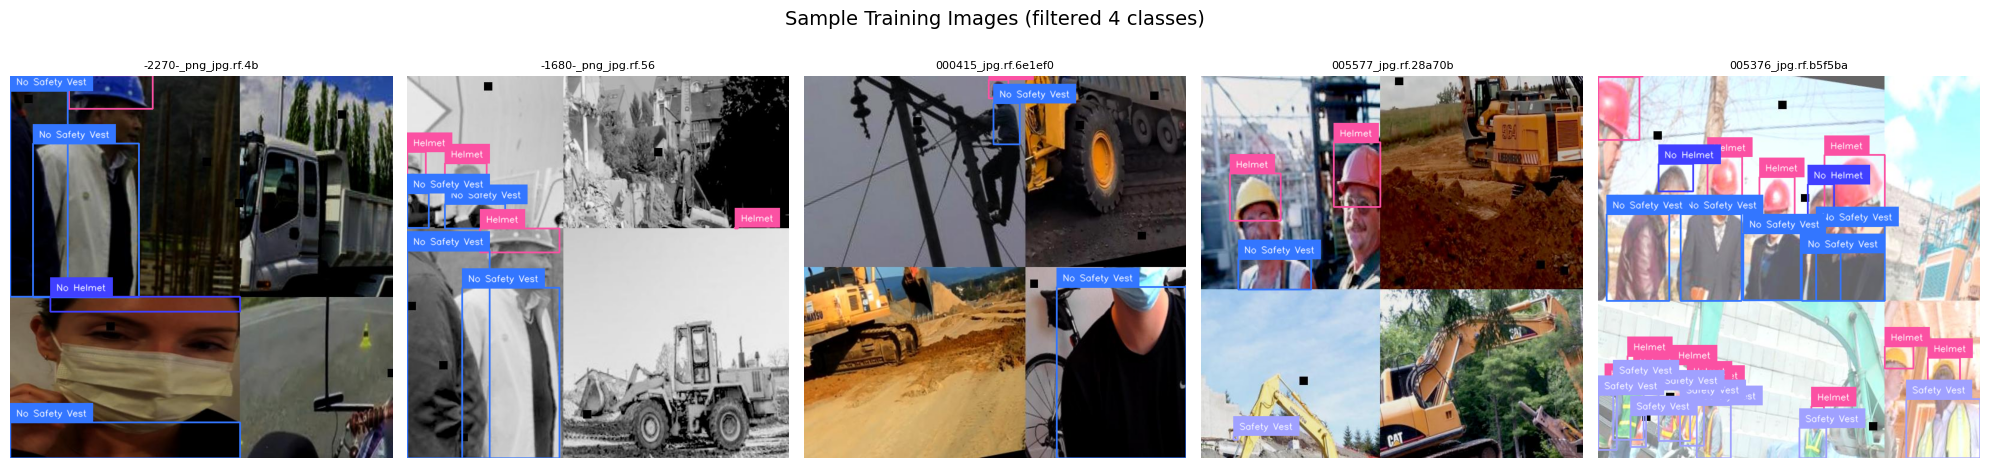

Dataset preparation complete.


In [ ]:
# ── Visualize 5 annotated samples ─────────────────────────────────────────────
# Colour per class: Helmet=green, No Helmet=red, Safety Vest=cyan, No Safety Vest=orange
CLASS_COLORS = {
    0: sv.Color.GREEN,
    1: sv.Color.RED,
    2: sv.Color(0, 200, 255),   # cyan
    3: sv.Color(255, 140, 0),   # orange
}

train_imgs = sorted((Path(DATASET_OUT) / "train" / "images").glob("*"))[:200]
sample_imgs = random.sample(train_imgs, min(5, len(train_imgs)))

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, img_path in zip(axes, sample_imgs):
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w  = image.shape[:2]

    lbl_path = Path(DATASET_OUT) / "train" / "labels" / (img_path.stem + ".txt")
    xyxy_list, class_ids = [], []

    if lbl_path.exists():
        for line in open(lbl_path):
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:5])
            x1 = int((cx - bw / 2) * w)
            y1 = int((cy - bh / 2) * h)
            x2 = int((cx + bw / 2) * w)
            y2 = int((cy + bh / 2) * h)
            xyxy_list.append([x1, y1, x2, y2])
            class_ids.append(cls)

    if xyxy_list:
        dets = sv.Detections(
            xyxy=np.array(xyxy_list, dtype=np.float32),
            class_id=np.array(class_ids)
        )
        ba = sv.BoxAnnotator()
        la = sv.LabelAnnotator()
        labels = [CLASS_NAMES[c] for c in class_ids]
        image  = ba.annotate(scene=image, detections=dets)
        image  = la.annotate(scene=image, detections=dets, labels=labels)

    ax.imshow(image)
    ax.axis("off")
    ax.set_title(img_path.name[:20], fontsize=8)

plt.suptitle("Sample Training Images (filtered 4 classes)", fontsize=14)
plt.tight_layout()
plt.show()
print("Dataset preparation complete.")

---
### Cell 3: Train RT-DETRv4-X
Standard Ultralytics RTDETR API. No subclassing. Saves checkpoints to Drive every 10 epochs.

In [ ]:
from ultralytics import RTDETR

# Load pretrained RT-DETRv4-X weights (downloads automatically on first run)
model = RTDETR("rtdetr-x.pt")

# ── Train ────────────────────────────────────────────────────────────────────
# All augmentation specified here — no mid-run mutation.
# save_period=10 ensures Drive has checkpoints every 10 epochs (Colab reset safety).
results = model.train(
    data         = YAML_PATH,
    epochs       = 15,
    imgsz        = 640,
    batch        = 16,
    optimizer    = "AdamW",
    lr0          = 2e-4,
    weight_decay = 1e-4,
    cos_lr       = True,
    warmup_epochs= 3,
    amp          = True,          # FP16 mixed precision
    patience     = 20,            # early stopping
    workers      = 4,
    project      = BASE_DIR,
    name         = "rtdetr_run",
    exist_ok     = True,
    save_period  = 10,            # save checkpoint every 10 epochs
    # Augmentation args (standard Ultralytics — no dynamic mutation)
    mosaic       = 0.5,
    fliplr       = 0.5,
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,
    scale        = 0.5,
)

print("Training complete.")
print("Best checkpoint:", results.save_dir)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/ppe_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-x.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=rtdetr_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, pers

       1/15      9.06G      1.701      1.274     0.9801         53        640: 22% ━━╸───────── 68/307 1.1it/s 2:15<3:40WARNING ⚠️ CUDA out of memory with batch=8. Reducing to batch=4 and retrying (2/3).
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 394.3±459.1 MB/s, size: 48.9 KB)
train: Scanning /content/dataset/train/labels.cache... 2452 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2452/2452 791.1Mit/s 0.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 192.1±152.5 MB/s, size: 42.8 KB)
val: Scanning /content/dataset/valid/labels.cache... 81 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 81/81 6.1Mit/s 0.0s
optimizer: AdamW(lr=0.0002, momentum=0.937) with parameter groups 193 weight(decay=0.0), 256 weight(decay=0.0001), 276 bias(decay=0.0)
       1/15  

       1/15      5.39G      1.362     0.7167     0.6544         17        640: 100% ━━━━━━━━━━━━ 613/613 1.6it/s 6:13
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 5.8s/it 17.4s
                   all         81        295     0.0111      0.167     0.0162    0.00353

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/15      5.45G      1.343     0.7442     0.6491         22        640: 0% ──────────── 0/613  1.2s

       2/15      5.45G     0.9851      1.054     0.3811         15        640: 100% ━━━━━━━━━━━━ 613/613 1.8it/s 5:41
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.6s
                   all         81        295     0.0748      0.343     0.0482     0.0222

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/15      7.16G     0.5767      1.329     0.2213         18        640: 0% ──────────── 0/613  0.8s

       3/15      7.16G     0.8098      1.107     0.2815         18        640: 100% ━━━━━━━━━━━━ 613/613 1.9it/s 5:31
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.5s
                   all         81        295     0.0811      0.374     0.0915     0.0474

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       4/15      7.16G      1.131     0.9153     0.3802         24        640: 0% ──────────── 0/613  0.7s

...

      10/15      7.17G     0.5423     0.7834     0.1738         16        640: 100% ━━━━━━━━━━━━ 613/613 1.8it/s 5:34
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.5s
                   all         81        295      0.708      0.601       0.62      0.344

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      11/15      7.17G     0.9186     0.4395    0.09692         18        640: 0% ──────────── 0/613  1.7s

      11/15      7.17G     0.5412     0.6476     0.1778         10        640: 100% ━━━━━━━━━━━━ 613/613 1.8it/s 5:35
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.5s
                   all         81        295      0.722      0.567      0.637      0.346

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      12/15      7.17G     0.7386     0.5619    0.09754         49        640: 0% ──────────── 0/613  1.8s

      12/15      7.17G     0.5338     0.6117     0.1755         12        640: 100% ━━━━━━━━━━━━ 613/613 1.8it/s 5:35
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.2it/s 2.5s
                   all         81        295      0.803       0.61      0.676       0.38

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      13/15      7.17G     0.8653     0.4561     0.1571         13        640: 0% ──────────── 0/613  0.7s

      13/15      7.17G     0.5218     0.6055     0.1659          8        640: 100% ━━━━━━━━━━━━ 613/613 1.9it/s 5:31
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3it/s 2.3s
                   all         81        295      0.772      0.666      0.689      0.382

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      14/15      7.17G     0.2362     0.5177     0.1011          9        640: 0% ──────────── 0/613  0.8s

      14/15      7.17G      0.514     0.5946     0.1621         29        640: 26% ━━━───────── 160/613 2.0it/s 1:31<3:44

---
### Cell 4: Evaluation on Test Set
Load best checkpoint, run `model.val()`, compute per-class classification metrics,
FPS benchmark, and save all outputs to Drive.

In [ ]:
import time, json
import numpy as np
from pathlib import Path
from ultralytics import RTDETR
from sklearn.metrics import (
    precision_score, recall_score, f1_score, matthews_corrcoef
)

BEST_PT   = f"{BASE_DIR}/rtdetr_run/weights/best.pt"
CONF_THR  = 0.5
CLASS_NAMES = ["Helmet", "No Helmet", "Safety Vest", "No Safety Vest"]

# ── Load best checkpoint ──────────────────────────────────────────────────────
model = RTDETR(BEST_PT)
print(f"Loaded: {BEST_PT}")

# ── model.val() on test split ─────────────────────────────────────────────────
val_res = model.val(
    data   = YAML_PATH,
    split  = "test",
    imgsz  = 640,
    batch  = 16,
    workers= 4,
    conf   = CONF_THR,
)

# Extract mAP metrics from val results
map50    = float(val_res.box.map50)
map75    = float(val_res.box.map75) if hasattr(val_res.box, 'map75') else float(val_res.box.map)
map5095  = float(val_res.box.map)
# Per-class AP at IoU=0.5 (list, one value per class)
class_ap50 = val_res.box.ap50.tolist() if hasattr(val_res.box.ap50, 'tolist') else list(val_res.box.ap50)

print(f"mAP@50    : {map50:.4f}")
print(f"mAP@75    : {map75:.4f}")
print(f"mAP@50:95 : {map5095:.4f}")
for i, cname in enumerate(CLASS_NAMES):
    ap = class_ap50[i] if i < len(class_ap50) else float('nan')
    print(f"  AP@50 [{cname}]: {ap:.4f}")

In [ ]:
# ── Per-image inference for classification metrics ────────────────────────────
# Run inference on each test image; assign predicted class = highest-conf detection
# Ground truth class = class of first annotation in label file

test_img_dir = Path(DATASET_OUT) / "test" / "images"
test_lbl_dir = Path(DATASET_OUT) / "test" / "labels"

y_true, y_pred = [], []

test_images = sorted(test_img_dir.glob("*"))

for img_path in test_images:
    lbl_path = test_lbl_dir / (img_path.stem + ".txt")
    if not lbl_path.exists():
        continue

    # Ground truth: collect all class IDs in this image
    gt_classes = []
    for line in open(lbl_path):
        parts = line.strip().split()
        if parts:
            gt_classes.append(int(parts[0]))
    if not gt_classes:
        continue

    # Run inference
    preds = model.predict(str(img_path), conf=CONF_THR, imgsz=640, verbose=False)[0]
    boxes = preds.boxes

    # Build per-class y_true / y_pred (one entry per GT annotation)
    if len(boxes) > 0:
        pred_cls_list   = boxes.cls.cpu().numpy().astype(int).tolist()
        pred_conf_list  = boxes.conf.cpu().numpy().tolist()
    else:
        pred_cls_list, pred_conf_list = [], []

    # For each GT class in this image, find best matching prediction
    for gt_cls in gt_classes:
        y_true.append(gt_cls)
        if pred_cls_list:
            # Pick highest confidence prediction overall (image-level assignment)
            best_idx = int(np.argmax(pred_conf_list))
            y_pred.append(pred_cls_list[best_idx])
        else:
            # No prediction — assign a dummy class (penalises recall)
            y_pred.append(-1)   # will be treated as wrong

# Replace -1 with a 'background' class index (4) for sklearn
y_true_np = np.array(y_true)
y_pred_np = np.array([p if p >= 0 else 4 for p in y_pred])

labels_4 = [0, 1, 2, 3]  # only score on 4 real classes

prec_per_class  = precision_score(y_true_np, y_pred_np, labels=labels_4,
                                   average=None, zero_division=0)
rec_per_class   = recall_score   (y_true_np, y_pred_np, labels=labels_4,
                                   average=None, zero_division=0)
f1_per_class    = f1_score       (y_true_np, y_pred_np, labels=labels_4,
                                   average=None, zero_division=0)

# MCC per class (one-vs-rest)
mcc_per_class = []
for c in labels_4:
    yt_bin = (y_true_np == c).astype(int)
    yp_bin = (y_pred_np == c).astype(int)
    mcc_per_class.append(float(matthews_corrcoef(yt_bin, yp_bin)))

print("\nPer-class classification metrics (conf >= 0.5):")
for i, cname in enumerate(CLASS_NAMES):
    print(f"  {cname:20s} | P={prec_per_class[i]:.3f}  R={rec_per_class[i]:.3f}  "
          f"F1={f1_per_class[i]:.3f}  MCC={mcc_per_class[i]:.3f}")

In [ ]:
# ── Confusion matrix (4x4) ────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

# Filter to only GT samples in 0-3 range
mask   = y_true_np < 4
cm     = confusion_matrix(y_true_np[mask],
                          np.clip(y_pred_np[mask], 0, 3),
                          labels=[0, 1, 2, 3])
print("Confusion matrix (4x4):\n", cm)

# ── FPS Benchmark — FP16, batch=1, T4 GPU ────────────────────────────────────
import torch

dummy_img = test_images[0]

# Warm up (not timed)
for _ in range(10):
    model.predict(str(dummy_img), imgsz=640, half=True, verbose=False)

# Timed runs
N_RUNS = 100
torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(N_RUNS):
    model.predict(str(dummy_img), imgsz=640, half=True, verbose=False)
torch.cuda.synchronize()
elapsed = time.perf_counter() - t0
fps = N_RUNS / elapsed
print(f"\nFPS (FP16, batch=1, T4): {fps:.2f}")

In [ ]:
# ── Save all metrics to Drive ─────────────────────────────────────────────────

class_ap_dict = {CLASS_NAMES[i]: (class_ap50[i] if i < len(class_ap50) else 0.0)
                 for i in range(4)}

metrics = {
    "model": "RT-DETRv4-X",
    "detection": {
        "mAP@50"   : map50,
        "mAP@75"   : map75,
        "mAP@50:95": map5095,
        "class_AP" : class_ap_dict,
    },
    "classification": {
        CLASS_NAMES[i]: {
            "Precision": float(prec_per_class[i]),
            "Recall"   : float(rec_per_class[i]),
            "F1"       : float(f1_per_class[i]),
            "MCC"      : float(mcc_per_class[i]),
        }
        for i in range(4)
    },
    "fps": fps,
}

# rtdetr_metrics.json
with open(f"{BASE_DIR}/rtdetr_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# rtdetr_classwise_ap.json
with open(f"{BASE_DIR}/rtdetr_classwise_ap.json", "w") as f:
    json.dump(class_ap_dict, f, indent=2)

# rtdetr_confusion_matrix.npy
np.save(f"{BASE_DIR}/rtdetr_confusion_matrix.npy", cm)

# rtdetr_fps.txt
with open(f"{BASE_DIR}/rtdetr_fps.txt", "w") as f:
    f.write(str(fps))

print("All metrics saved to Drive.")
print(json.dumps(metrics, indent=2))

---
### Cell 5: Visualizations
Training curves, mAP curve, confusion matrix heatmap, PR curves. Saved to `rtdetr_plots/`.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PLOT_DIR = f"{BASE_DIR}/rtdetr_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

RESULTS_CSV = f"{BASE_DIR}/rtdetr_run/results.csv"

# ── Load results.csv ──────────────────────────────────────────────────────────
if not Path(RESULTS_CSV).exists():
    print(f"WARNING: {RESULTS_CSV} not found. Training may not have completed.")
else:
    df = pd.read_csv(RESULTS_CSV)
    df.columns = df.columns.str.strip()  # strip whitespace from column names
    print("results.csv columns:", df.columns.tolist())
    print(df.head())

In [ ]:
# ── Plot 1: Box Loss + Cls Loss ───────────────────────────────────────────────
# Column names vary slightly by Ultralytics version; try multiple candidates
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    # fuzzy fallback
    for c in df.columns:
        for cand in candidates:
            if cand.lower().replace("/","") in c.lower().replace("/",""):
                return c
    return None

box_loss_col = find_col(df, ["train/box_loss", "train/box_om", "train/loss", "box_loss"])
cls_loss_col = find_col(df, ["train/cls_loss", "train/cls_om", "cls_loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = df["epoch"] if "epoch" in df.columns else range(len(df))

if box_loss_col:
    axes[0].plot(epochs, df[box_loss_col], color="steelblue", linewidth=2)
    axes[0].set_title("Training Box Loss", fontsize=13)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, "box_loss column not found", ha="center")

if cls_loss_col:
    axes[1].plot(epochs, df[cls_loss_col], color="coral", linewidth=2)
    axes[1].set_title("Training Cls Loss", fontsize=13)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "cls_loss column not found", ha="center")

plt.suptitle("RT-DETRv4-X Training Losses", fontsize=15)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: loss_curves.png")

In [ ]:
# ── Plot 2: mAP@50 over epochs ────────────────────────────────────────────────
map50_col = find_col(df, ["metrics/mAP50(B)", "metrics/mAP_0.5", "val/mAP50", "mAP50"])

fig, ax = plt.subplots(figsize=(10, 5))
if map50_col:
    ax.plot(epochs, df[map50_col], color="green", linewidth=2)
    ax.set_title("Validation mAP@50 Over Epochs", fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP@50")
    ax.grid(True, alpha=0.3)
    best_epoch = df[map50_col].idxmax()
    ax.axvline(x=float(epochs.iloc[best_epoch]), color="red", linestyle="--",
               label=f"Best epoch: {int(epochs.iloc[best_epoch])}")
    ax.legend()
else:
    ax.text(0.5, 0.5, "mAP50 column not found", ha="center")
    print("Available columns:", df.columns.tolist())

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/map50_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: map50_curve.png")

In [ ]:
# ── Plot 3: Confusion Matrix Heatmap ─────────────────────────────────────────
cm_loaded = np.load(f"{BASE_DIR}/rtdetr_confusion_matrix.npy")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_loaded,
    annot=True, fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap="Blues",
    ax=ax
)
ax.set_title("RT-DETRv4-X Confusion Matrix", fontsize=13)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

In [ ]:
# ── Plot 4: PR Curves per class ───────────────────────────────────────────────
# Check if Ultralytics saved PR curve data
pr_data_path = Path(f"{BASE_DIR}/rtdetr_run")
# Ultralytics saves PR curve numpy arrays in the run folder
# px = recall points, py = precision values per class

# Try to load from val results object (still in memory from Cell 4)
# If val_res object is available and has curves attribute:
try:
    # val_res.box.pr_curve contains (px, py, ap) for the val/test run
    px    = val_res.box.px    # shape: [num_thresholds]
    py    = val_res.box.py    # shape: [num_classes, num_thresholds]
    ap_50 = val_res.box.ap50  # per-class AP@50

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["green", "red", "dodgerblue", "orange"]
    for i, (cname, color) in enumerate(zip(CLASS_NAMES, colors)):
        if i < py.shape[0]:
            ax.plot(px, py[i], label=f"{cname} (AP={ap_50[i]:.3f})",
                    color=color, linewidth=2)

    ax.set_title("PR Curves per Class — RT-DETRv4-X", fontsize=13)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(loc="lower left")
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/pr_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: pr_curves.png")

except AttributeError:
    # Fallback: plot class-wise AP as bar chart if curve data unavailable
    print("PR curve data not available via val_res.box — generating AP bar chart instead.")
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(CLASS_NAMES, [class_ap_dict[c] for c in CLASS_NAMES],
                  color=["green", "red", "dodgerblue", "orange"])
    for bar, val in zip(bars, [class_ap_dict[c] for c in CLASS_NAMES]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", fontsize=10)
    ax.set_title("Class-wise AP@50 — RT-DETRv4-X", fontsize=13)
    ax.set_ylabel("AP@50")
    ax.set_ylim([0, 1.1])
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/pr_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: pr_curves.png (AP bar chart fallback)")

print("\nAll 4 plots saved to:", PLOT_DIR)

---
### Cell 6: Inference Demo
Run on 10 random test images. Green = compliant, Red = violation. 2×5 grid + violation table.

In [ ]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import RTDETR

CLASS_NAMES = ["Helmet", "No Helmet", "Safety Vest", "No Safety Vest"]
# Compliance classes (Green): Helmet=0, Safety Vest=2
# Violation classes (Red):    No Helmet=1, No Safety Vest=3
COMPLIANT   = {0, 2}
VIOLATION   = {1, 3}

BOX_GREEN = (0, 220, 0)    # BGR for compliant
BOX_RED   = (0, 0, 220)    # BGR for violation
CONF_THR  = 0.5

model = RTDETR(BEST_PT)

# ── Select 10 random test images ──────────────────────────────────────────────
test_imgs = sorted((Path(DATASET_OUT) / "test" / "images").glob("*"))
demo_imgs = random.sample(test_imgs, min(10, len(test_imgs)))

annotated = []       # stores RGB annotated images
summary_rows = []    # for violation table

for img_path in demo_imgs:
    frame = cv2.imread(str(img_path))
    h, w  = frame.shape[:2]

    # Run inference
    result  = model.predict(str(img_path), conf=CONF_THR, imgsz=640, verbose=False)[0]
    boxes   = result.boxes

    compliant_count  = 0
    violation_count  = 0
    violation_labels = []

    if len(boxes) > 0:
        for box in boxes:
            cls  = int(box.cls[0])
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

            # Choose colour based on compliance
            color = BOX_GREEN if cls in COMPLIANT else BOX_RED

            # Draw bounding box
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            # Draw label: "ClassName 0.87"
            label = f"{CLASS_NAMES[cls]} {conf:.2f}"
            (lw, lh), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(frame, (x1, y1 - lh - baseline - 4),
                          (x1 + lw, y1), color, -1)
            cv2.putText(frame, label, (x1, y1 - baseline - 2),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

            if cls in COMPLIANT:
                compliant_count += 1
            else:
                violation_count += 1
                violation_labels.append(CLASS_NAMES[cls])

    annotated.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    summary_rows.append({
        "Image"      : img_path.name[:25],
        "Compliant"  : compliant_count,
        "Violations" : violation_count,
        "Violation Types": ", ".join(set(violation_labels)) if violation_labels else "None",
    })

# ── Display 2×5 grid ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for ax, img, row in zip(axes.flat, annotated, summary_rows):
    ax.imshow(img)
    ax.axis("off")
    title_color = "red" if row["Violations"] > 0 else "green"
    ax.set_title(f"V:{row['Violations']} C:{row['Compliant']}",
                 color=title_color, fontsize=9)

plt.suptitle("RT-DETRv4-X Inference — Green=Compliant  Red=Violation",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/rtdetr_plots/inference_demo.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Per-image violation summary ───────────────────────────────────────────────
import pandas as pd
summary_df = pd.DataFrame(summary_rows)
print("\nPer-image Violation Summary:")
print(summary_df.to_string(index=False))

---
### Cell 7: Export & Confirm
Verify all required files exist on Drive and print sizes.

In [ ]:
import os
from pathlib import Path

BASE_DIR = "/drive/MyDrive/ppe_results"

# Required files / directories to verify
required = [
    "rtdetr_metrics.json",
    "rtdetr_classwise_ap.json",
    "rtdetr_confusion_matrix.npy",
    "rtdetr_fps.txt",
    "rtdetr_plots/loss_curves.png",
    "rtdetr_plots/map50_curve.png",
    "rtdetr_plots/confusion_matrix.png",
    "rtdetr_plots/pr_curves.png",
    "rtdetr_run/weights/best.pt",
]

print(f"{'File':<45} {'Status':<10} {'Size':>10}")
print("-" * 70)
all_ok = True

for rel_path in required:
    full = Path(BASE_DIR) / rel_path
    if full.exists():
        size_kb = full.stat().st_size / 1024
        print(f"{rel_path:<45} {'✅ OK':<10} {size_kb:>8.1f} KB")
    else:
        print(f"{rel_path:<45} {'❌ MISSING':<10} {'—':>10}")
        all_ok = False

print("-" * 70)
if all_ok:
    print("\n✅ Notebook 1 complete. All outputs saved to Drive.")
else:
    print("\n⚠️  Some files are missing. Re-run the relevant cells.")